In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import accumulate, product, chain
import torch

nCells = (10,10,10)
cellSize = (3,3,12)
n = 2.2 # PWO refractive index
c0 = 299.792458/n # mm/ns
c = c0/n

In [3]:
def onAxis_SolidAngle(a, b, d):
    alpha = a / (2*d)
    beta  = b / (2*d)
    alpha_sq = alpha * alpha
    beta_sq  = beta  * beta
    return 4*np.arcsin(alpha*beta / np.sqrt((1 + alpha_sq) * (1 + beta_sq)))

def offAxis_SolidAngle(A, B, a, b, d):
    sign_A = 1 if A >= 0 else -1
    sign_B = 1 if B >= 0 else -1
    A_abs = A * sign_A
    B_abs = B * sign_B

    # Precompute alpha/beta values shared across the 4 onAxis calls
    inv_d = 1.0 / d
    alpha1 = (a + sign_A*A_abs) * inv_d   # used by o1, o3
    alpha2 = A_abs              * inv_d   # used by o2, o4
    beta1  = (b + sign_B*B_abs) * inv_d   # used by o1, o2
    beta2  = B_abs              * inv_d   # used by o3, o4

    # Precompute 1 + x^2 terms shared across calls
    a1sq = 1 + alpha1 * alpha1
    a2sq = 1 + alpha2 * alpha2
    b1sq = 1 + beta1  * beta1
    b2sq = 1 + beta2  * beta2

    o1 = 4 * np.arcsin(alpha1 * beta1 / np.sqrt(a1sq * b1sq))
    o2 = 4 * np.arcsin(alpha2 * beta1 / np.sqrt(a2sq * b1sq))
    o3 = 4 * np.arcsin(alpha1 * beta2 / np.sqrt(a1sq * b2sq))
    o4 = 4 * np.arcsin(alpha2 * beta2 / np.sqrt(a2sq * b2sq))

    return (o1 - sign_A*o2 - sign_B*o3 + sign_A*sign_B*o4) / 4

def _offAxis_SolidAngle_vec(A, B, a, b, d):
    """Vectorised offAxis_SolidAngle: A, B can be numpy arrays, d is a scalar."""
    sign_A = np.where(A >= 0, 1.0, -1.0)
    sign_B = np.where(B >= 0, 1.0, -1.0)
    A_abs  = np.abs(A)
    B_abs  = np.abs(B)

    inv_d  = 1.0 / d
    alpha1 = (a + sign_A*A_abs) * inv_d
    alpha2 = A_abs              * inv_d
    beta1  = (b + sign_B*B_abs) * inv_d
    beta2  = B_abs              * inv_d

    a1sq = 1.0 + alpha1 * alpha1
    a2sq = 1.0 + alpha2 * alpha2
    b1sq = 1.0 + beta1  * beta1
    b2sq = 1.0 + beta2  * beta2

    o1 = 4.0 * np.arcsin(np.clip(alpha1 * beta1 / np.sqrt(a1sq * b1sq), -1.0, 1.0))
    o2 = 4.0 * np.arcsin(np.clip(alpha2 * beta1 / np.sqrt(a2sq * b1sq), -1.0, 1.0))
    o3 = 4.0 * np.arcsin(np.clip(alpha1 * beta2 / np.sqrt(a1sq * b2sq), -1.0, 1.0))
    o4 = 4.0 * np.arcsin(np.clip(alpha2 * beta2 / np.sqrt(a2sq * b2sq), -1.0, 1.0))

    return (o1 - sign_A * o2 - sign_B * o3 + sign_A * sign_B * o4) / 4.0


In [4]:
def generate_tuples_two_integers(n):
    """
    Generate all tuples of two integers (a, b) such that
    the sum of their absolute values equals n.

    Parameters:
        n (int): Target sum of absolute values.

    Returns:
        list of tuples: List of (a, b) satisfying the condition.
    """
    result = []
    for a in range(-n, n + 1):
        b_abs = n - abs(a)  # Always >= 0 for a in [-n, n]
        result.append((a, b_abs))
        if b_abs != 0:
            result.append((a, -b_abs))
    return result


def all_reflections(n):
    """
    Generate all possible reflection paths such that
    the total amount of reflections equals n. A reflection 
    path is a (x, y, z) tuple where each coordinate is a
    (positive or negative) integer which signifies the amount
    of times a ray reflected in that direction.
    Positive values mean that the ray first reflected in the face
    in the positive direction of the axis and viceversa.

    Parameters:
        n (int): Target number of reflections.

    Returns:
        list of tuples: List of (x,y,z) satisfying the condition.
    """
    paths_horizontal = generate_tuples_two_integers(n)
    paths_vertical = generate_tuples_two_integers(n-1)
    paths = [(x, 0, z) for x, z in paths_horizontal] + [(x, -1, z) for x, z in paths_vertical]
    return paths

def reflect(old_coordinates, reflection, nCells=nCells):

    def reflect_onedim(old_coordinate, reflection, nCell):
        nc = old_coordinate
        if reflection != 0:
            sign = 1 if reflection > 0 else -1
            reflection = abs(reflection)
            if reflection & 1:  # odd reflection count → partial flip
                nc = 2*nCell - 1 - old_coordinate if sign > 0 else -old_coordinate - 1
            nc += (reflection >> 1) * sign * 2 * nCell
        return nc
    
    nc = [reflect_onedim(oc, r, n) for oc, r, n in zip(old_coordinates, reflection, nCells)]

    return nc

In [5]:
def find_distances(edep_idx, sensor_idx, cellSize=cellSize, nCells=nCells):
    cs0, cs1, cs2 = cellSize
    shift_x = abs(edep_idx[0] - sensor_idx[0])
    A = -0.5*cs0 if shift_x == 0 else cs0*(shift_x - 0.5)
    d = cs1*(nCells[1] - 1 - edep_idx[1] + 0.5)
    shift_z = abs(edep_idx[2] - sensor_idx[1])
    B = -0.5*cs2 if shift_z == 0 else cs2*(shift_z - 0.5)
    t = np.sqrt(d*d + (shift_x*cs0)**2 + (shift_z*cs2)**2) / c
    return A, B, d, t

def compute_angles(edep_idx, sensor_idx, N, cellSize=cellSize):
    cs0, cs2 = cellSize[0], cellSize[2]
    omegas = []
    for n in range(N + 1):
        omegas_n = []
        for r in all_reflections(n):
            new_coord = reflect(edep_idx, r)
            A, B, d, t = find_distances(new_coord, sensor_idx, cellSize, nCells)
            omegas_n.append((offAxis_SolidAngle(A, B, cs0, cs2, d), t))
        omegas.append(omegas_n)
    return omegas

# Plots

In [ ]:
def compute_solid_angles_vs_reflections(edep_idx, N):
    """Sum solid angles over all sensor positions for each reflection order."""
    additional = np.zeros(N + 1)
    for i in range(nCells[0]):
        for j in range(nCells[2]):
            for n, paths in enumerate(compute_angles(edep_idx, (i, j), N)):
                additional[n] += sum(omega for omega, _ in paths)
    return additional, np.cumsum(additional)

In [15]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

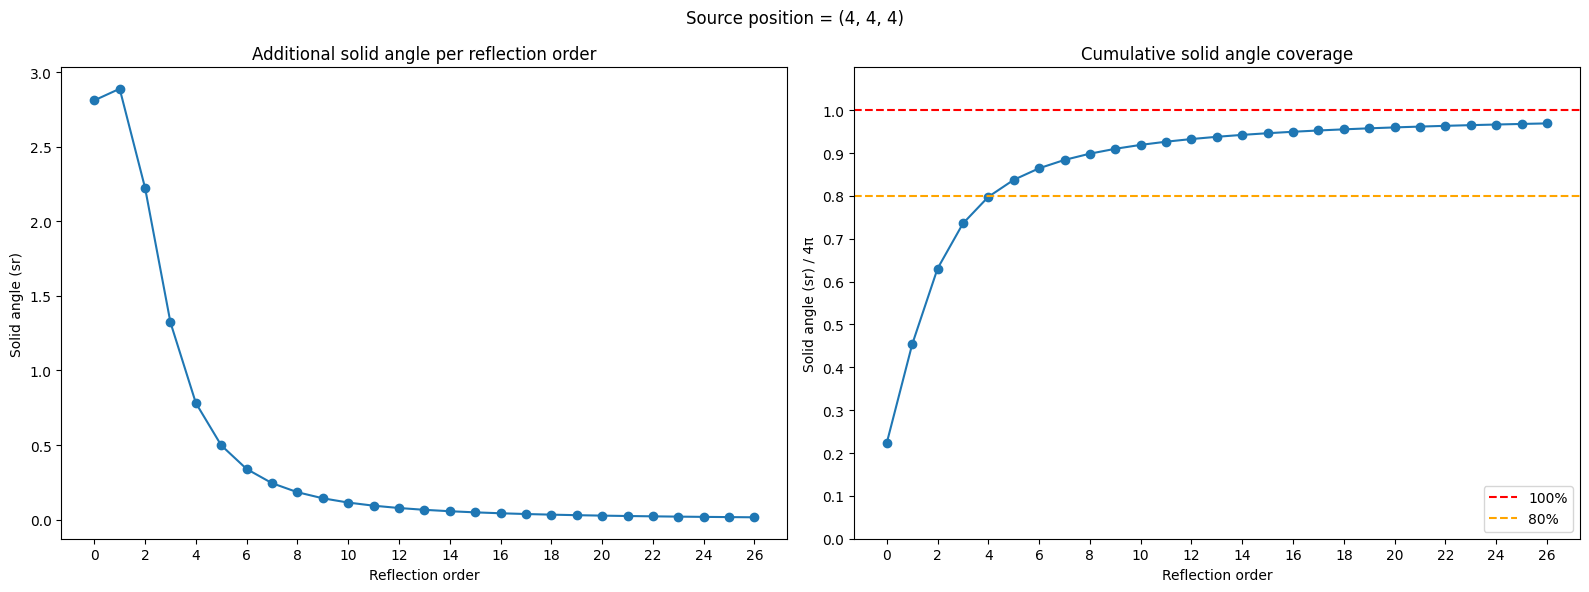

In [99]:
edep_idx = (4,4,4)
N = 26
ns = np.arange(N + 1)
additional, cumulative = compute_solid_angles_vs_reflections(edep_idx, N)

# ── Plot 1: single edep_idx = (4, 4, 4), all sensors ────────────────────
fig1, (ax_add, ax_cum) = plt.subplots(1, 2, figsize=(16, 6))

ax_add.plot(ns, additional, marker='o', color=COLORS[0])
ax_add.set_xlabel('Reflection order')
ax_add.set_xticks(np.arange(0, N+1, 2))
ax_add.set_ylabel('Solid angle (sr)')
ax_add.set_title('Additional solid angle per reflection order')

ax_cum.plot(ns, cumulative/(4*np.pi), marker='o', color=COLORS[0])
ax_cum.axhline(1,   color='red',    linestyle='--', label='100%')
ax_cum.axhline(0.8, color='orange', linestyle='--', label='80%')
ax_cum.set_ylim(0, 1.1)
ax_cum.set_xlabel('Reflection order')
ax_cum.set_xticks(np.arange(0, N+1, 2))
ax_cum.set_ylabel('Solid angle (sr) / 4π')
ax_cum.set_yticks(np.arange(0, 1.1, 0.1))
ax_cum.set_title('Cumulative solid angle coverage')
ax_cum.legend(loc='lower right')

fig1.suptitle('Source position = (4, 4, 4)')
fig1.tight_layout()
fig1.savefig('solid_angle_single.png', dpi=150)

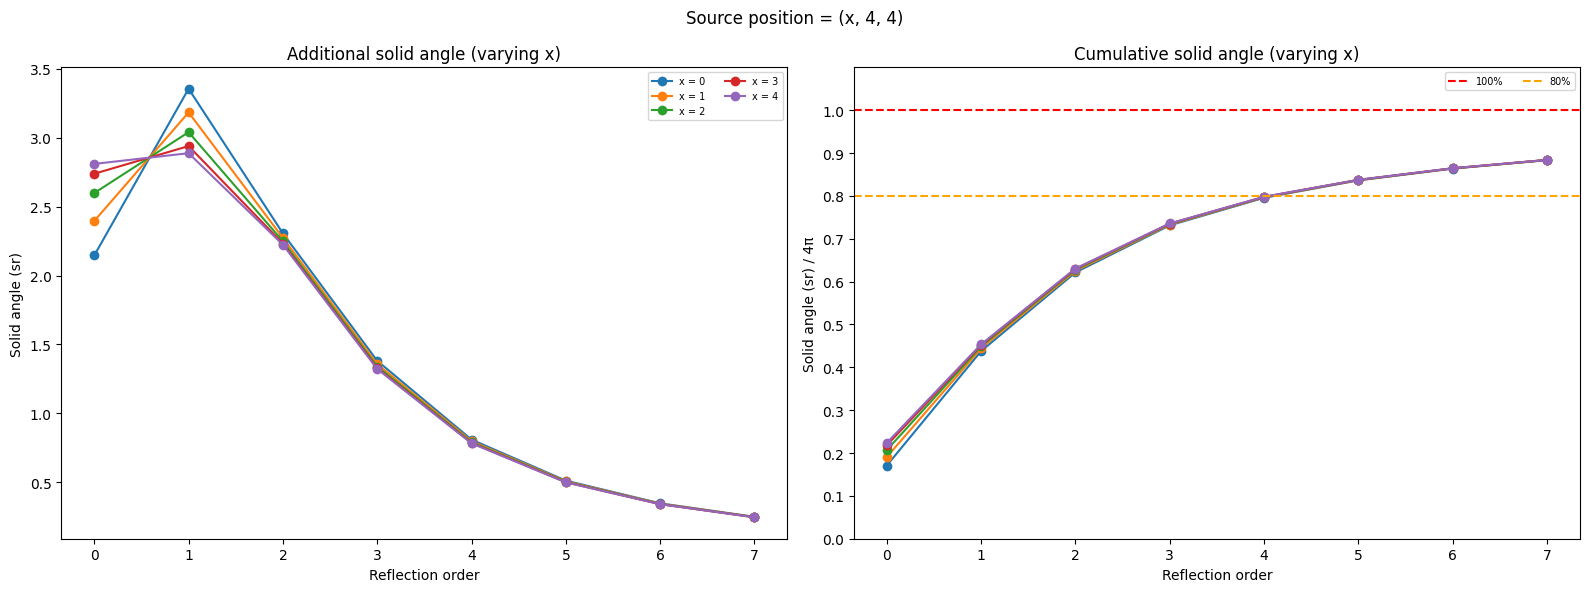

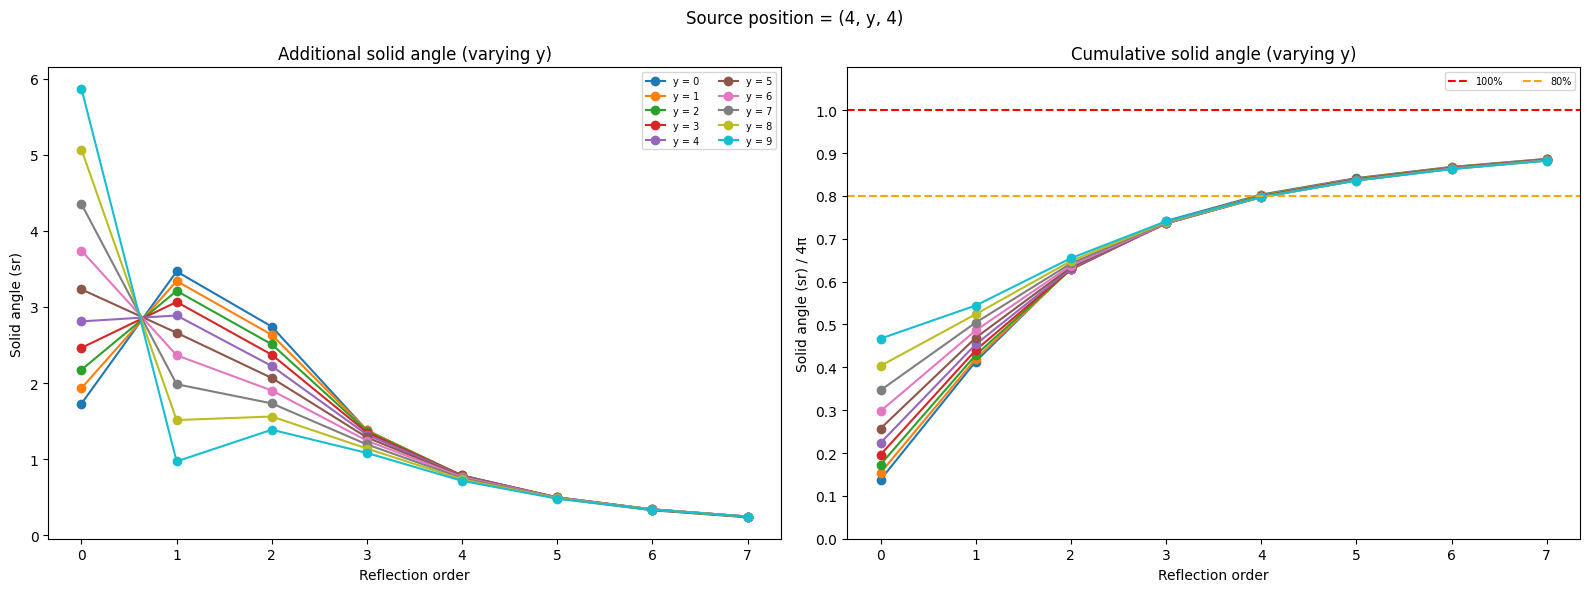

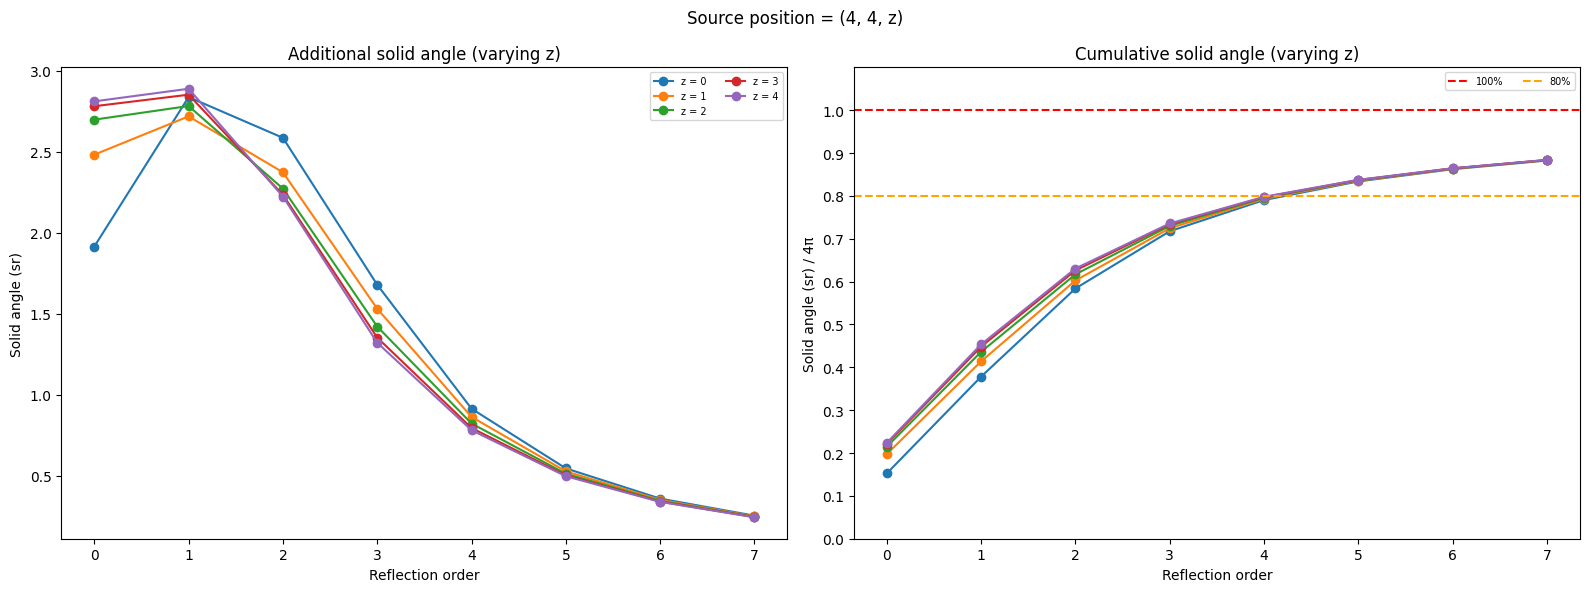

In [101]:
N = 7
ns = np.arange(N + 1)
additional, cumulative = compute_solid_angles_vs_reflections(edep_idx, N)

# ── Plot 2: one line per coordinate value ────────────────────────────────
variations = [
    ('x', 0, [(v, 4, 4) for v in range(nCells[0]//2)]),
    ('y', 1, [(4, v, 4) for v in range(nCells[1])]),
    ('z', 2, [(4, 4, v) for v in range(nCells[2]//2)]),
]

for row, (coord, coord_idx, edep_list) in enumerate(variations):
    fig2, (ax_add, ax_cum) = plt.subplots(1, 2, figsize=(16, 6))
    for idx, edep in enumerate(edep_list):
        label = f'{coord} = {edep[coord_idx]}'
        add, cum = compute_solid_angles_vs_reflections(edep, N)
        ax_add.plot(ns, add,           marker='o', color=COLORS[idx], label=label)
        ax_cum.plot(ns, cum/(4*np.pi), marker='o', color=COLORS[idx])  # no label here

    ax_add.set_xlabel('Reflection order')
    ax_add.set_ylabel('Solid angle (sr)')
    ax_add.set_title(f'Additional solid angle (varying {coord})')

    ax_cum.set_xlabel('Reflection order')
    ax_cum.set_ylabel('Solid angle (sr) / 4π')  
    ax_cum.set_yticks(np.arange(0, 1.1, 0.1))
    ax_cum.set_ylim(0, 1.1)
    ax_cum.set_title(f'Cumulative solid angle (varying {coord})')
    ax_cum.axhline(1,   color='red',    linestyle='--', label='100%')
    ax_cum.axhline(0.8, color='orange', linestyle='--', label='80%')

    ax_add.legend(fontsize=7, ncol=2)
    ax_cum.legend(fontsize=7, ncol=2)

    # Build a title like "Source position = (x, 4, 4)"
    pos = ['4', '4', '4']
    pos[coord_idx] = coord
    fig2.suptitle(f'Source position = ({", ".join(pos)})')

    fig2.tight_layout()
    fig2.savefig(f'solid_angle_variations_{coord}.png', dpi=150)
    plt.show()

Computing heatmap grids for y = 0 …


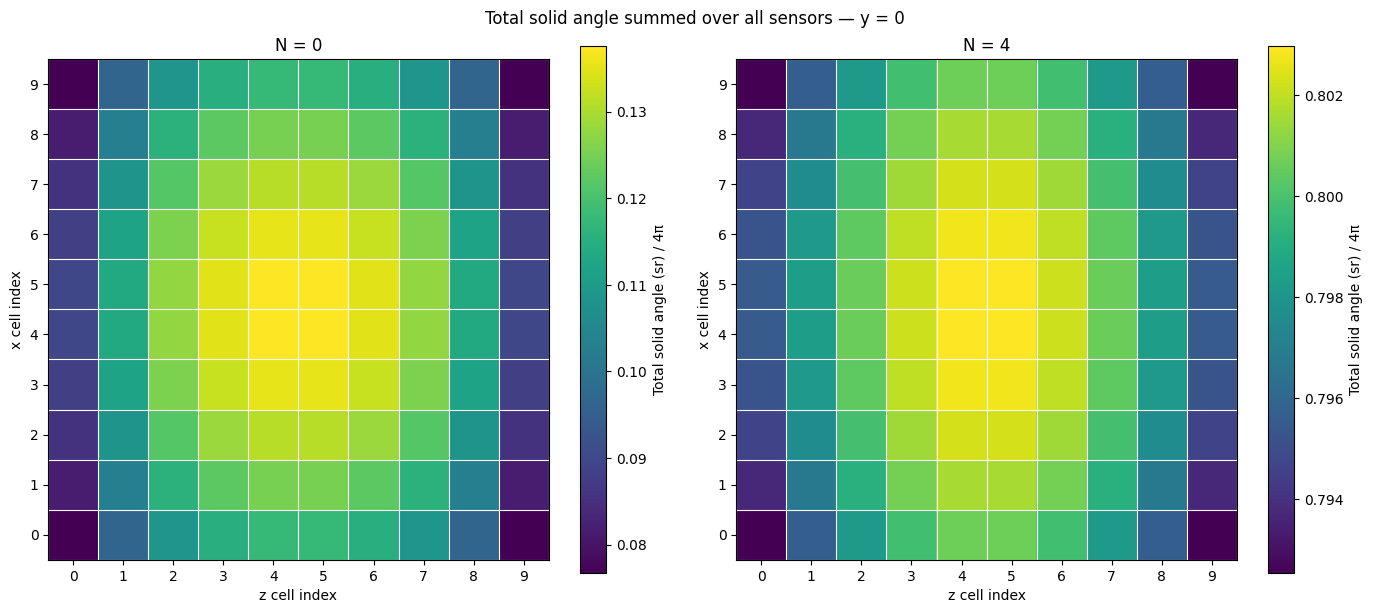

Computing heatmap grids for y = 4 …


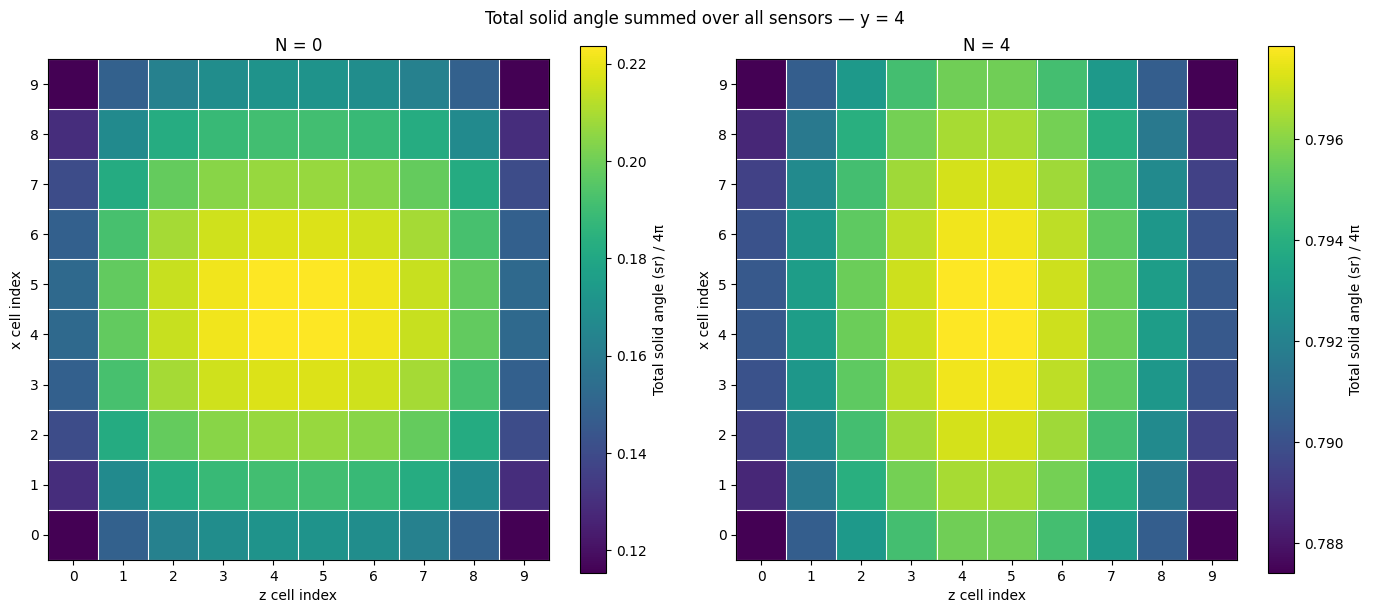

Computing heatmap grids for y = 9 …


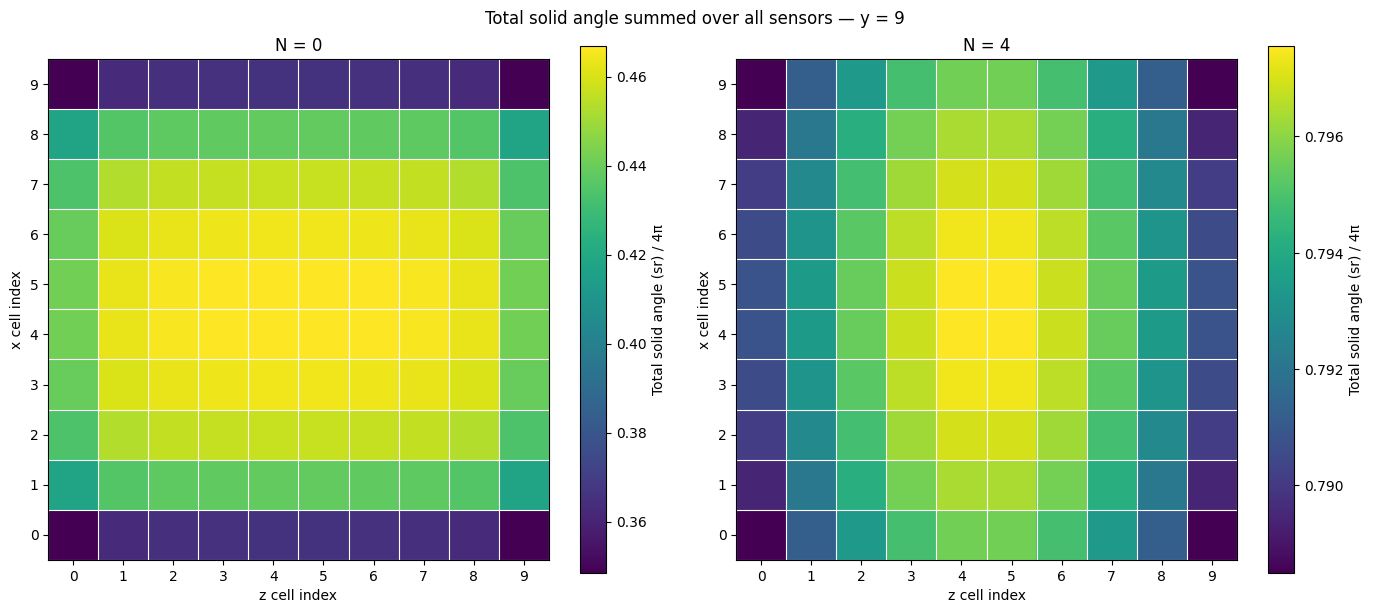

In [93]:
N_HEAT = 4
Y_SLICES = [0, 4, 9]

def compute_solid_angle_grids(y_idx, N_max):
    """Return two (nCells[0], nCells[2]) grids — N=0 and N=N_max —
    computed in a single pass over all (x, z) cells."""
    grid_N0   = np.zeros((nCells[0], nCells[2]))
    grid_Nmax = np.zeros((nCells[0], nCells[2]))
    for x in range(nCells[0]):
        for z in range(nCells[2]):
            _, cumulative = compute_solid_angles_vs_reflections((x, y_idx, z), N_max)
            grid_N0[x, z]   = cumulative[0]/(4*np.pi)
            grid_Nmax[x, z] = cumulative[N_max]/(4*np.pi)
    return grid_N0, grid_Nmax

def _style_heatmap_ax(ax, im, grid, label):
    """Apply per-axis colorbar, cell-centered ticks, and cell grid lines."""
    fig = ax.get_figure()
    fig.colorbar(im, ax=ax, label=label)
    # Major ticks centered on each cell (0 … nCells-1)
    ax.set_xticks(range(nCells[2]))
    ax.set_yticks(range(nCells[0]))
    # Minor ticks at cell boundaries (half-integer positions) for the grid
    ax.set_xticks(np.arange(-0.5, nCells[2], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nCells[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.8)
    ax.tick_params(which='minor', length=0)   # hide minor tick marks

for y_idx in Y_SLICES:
    print(f"Computing heatmap grids for y = {y_idx} …")
    grid_N0, grid_N4 = compute_solid_angle_grids(y_idx, N_HEAT)
    extent = [-0.5, nCells[2] - 0.5, -0.5, nCells[0] - 0.5]
    base_kw = dict(origin='lower', extent=extent, cmap='viridis', aspect='equal')
    fig3, (ax_n0, ax_n4) = plt.subplots(1, 2, figsize=(14, 6))
    im0 = ax_n0.imshow(grid_N0, vmin=grid_N0.min(), vmax=grid_N0.max(), **base_kw)
    ax_n0.set_xlabel('z cell index')
    ax_n0.set_ylabel('x cell index')
    ax_n0.set_title('N = 0')
    _style_heatmap_ax(ax_n0, im0, grid_N0, 'Total solid angle (sr) / 4π')
    im4 = ax_n4.imshow(grid_N4, vmin=grid_N4.min(), vmax=grid_N4.max(), **base_kw)
    ax_n4.set_xlabel('z cell index')
    ax_n4.set_ylabel('x cell index')
    ax_n4.set_title(f'N = {N_HEAT}')
    _style_heatmap_ax(ax_n4, im4, grid_N4, 'Total solid angle (sr) / 4π')
    fig3.suptitle(f'Total solid angle summed over all sensors — y = {y_idx}')
    fig3.tight_layout()
    fig3.savefig(f'solid_angle_heatmap_y{y_idx}.png', dpi=150)
    plt.show()

# Matrix

In [16]:
def build_solid_angle_matrix(N, save_path, cellSize=cellSize, nCells=nCells, eps=0.98, mu=0.004):
    """
    Build and save the solid angle/time matrix for all cells, sensors, and
    reflection paths up to order N.

    Parameters
    ----------
    N : int
        Maximum reflection order (inclusive).
    save_path : str
        File path where the resulting array will be saved (.npy format).
    cellSize : tuple of float
        (cs0, cs1, cs2) — physical size of each cell in mm along x, y, z.
    nCells : tuple of int
        (nCellsX, nCellsY, nCellsZ) — number of cells along each axis.
        Sensors tile the entire y = nCellsY face, so nSensorsX = nCellsX
        and nSensorsZ = nCellsZ.
    eps : float
        If not None, multiply each solid angle by eps**k,
        where k is the reflection order.
    mu : float
        If not None, multiply each solid angle by exp(-0.004 * path_length),
        where path_length = t * c is the full 3D optical path length from
        virtual image to sensor (mm).

    Returns
    -------
    matrix : np.ndarray, shape (nCellsX, nCellsY, nCellsZ, N_tot, nSensorsX, nSensorsZ, 2)
        matrix[cx, cy, cz, n, sx, sz, 0] — solid angle (sr) subtended by
            sensor (sx, sz) from cell (cx, cy, cz) via the n-th reflection path,
            optionally attenuated.
        matrix[cx, cy, cz, n, sx, sz, 1] — corresponding travel time (ns).

    N_tot = sum(len(all_reflections(k)) for k in range(N + 1)).
    Paths are ordered by ascending reflection order, then by all_reflections().
    """
    nCellsX, nCellsY, nCellsZ = nCells
    nSensorsX, nSensorsZ = nCellsX, nCellsZ
    cs0, cs1, cs2 = cellSize

    # Flat list of (reflection_order, reflection_tuple) for all paths
    all_paths = [(k, r) for k in range(N + 1) for r in all_reflections(k)]
    N_tot = len(all_paths)

    matrix = np.zeros((nCellsX, nCellsY, nCellsZ, N_tot, nSensorsX, nSensorsZ, 2),
                      dtype=np.float64)

    # Sensor index grids, shape (nSensorsX, nSensorsZ) — built once
    sx_grid, sz_grid = np.meshgrid(np.arange(nSensorsX), np.arange(nSensorsZ),
                                   indexing='ij')

    for cx in range(nCellsX):
        print(f"  x = {cx}/{nCellsX - 1}")
        for cy in range(nCellsY):
            for cz in range(nCellsZ):
                for path_idx, (k, r) in enumerate(all_paths):
                    # Virtual image of (cx, cy, cz) — computed once per path,
                    # not once per sensor as in the naive version
                    ncx, ncy, ncz = reflect((cx, cy, cz), r, nCells)

                    # y-distance to sensor plane (scalar, same for all sensors)
                    d = cs1 * (nCells[1] - 1 - ncy + 0.5)

                    # Per-sensor shifts — vectorised over the full sensor grid
                    shift_x = np.abs(ncx - sx_grid)   # (nSensorsX, nSensorsZ)
                    shift_z = np.abs(ncz - sz_grid)

                    # A, B follow find_distances: cs*(shift - 0.5) equals -0.5*cs
                    # for shift=0 and cs*(shift-0.5)>0 for shift>0
                    A = cs0 * (shift_x - 0.5)
                    B = cs2 * (shift_z - 0.5)

                    # Full 3D path length and travel time, both shape (nSX, nSZ)
                    path_len = np.sqrt(d*d + (shift_x * cs0)**2 + (shift_z * cs2)**2)
                    t = path_len / c

                    omega = _offAxis_SolidAngle_vec(A, B, cs0, cs2, d)

                    if eps is not None:
                        omega = omega * eps**k 
                    if mu is not None:
                        omega = omega * np.exp(-mu * path_len)

                    matrix[cx, cy, cz, path_idx, :, :, 0] = omega
                    matrix[cx, cy, cz, path_idx, :, :, 1] = t

    # Save raw binary (no NumPy header) so C++ can read it with read_matrices().
    # The C++ code expects:
    #   - shape.txt  : space-separated dimension sizes on a single line
    #   - save_path  : flat row-major float64 values, no header
    matrix = np.ascontiguousarray(matrix)   # ensure C (row-major) order
    with open("shape.txt", "w") as f:
        f.write(" ".join(str(s) for s in matrix.shape) + "\n")
    matrix.tofile(save_path)
    print(f"Saved matrix shape {matrix.shape} to '{save_path}' and shape to 'shape.txt'")
    return matrix

In [ ]:
build_solid_angle_matrix(5, "emission_matrix_2.bin")

  x = 0/9
  x = 1/9
  x = 2/9
  x = 3/9
  x = 4/9
  x = 5/9
  x = 6/9
  x = 7/9
  x = 8/9
  x = 9/9
Saved matrix shape (10, 10, 10, 102, 10, 10, 2) to 'emision_matrix_2.bin' and shape to 'shape.txt'


array([[[[[[[3.86450557e-02, 4.60118313e-01],
            [3.04715578e-02, 4.99241159e-01],
            [1.73076252e-02, 6.01531673e-01],
            ...,
            [1.03905802e-03, 1.43206831e+00],
            [6.88815862e-04, 1.61672902e+00],
            [4.73422309e-04, 1.80329464e+00]],

           [[3.79997625e-02, 4.62660422e-01],
            [3.00286241e-02, 5.01585027e-01],
            [1.71285807e-02, 6.03478383e-01],
            ...,
            [1.03704672e-03, 1.43288710e+00],
            [6.87757333e-04, 1.61745434e+00],
            [4.72830379e-04, 1.80394495e+00]],

           [[3.61653078e-02, 4.70204296e-01],
            [2.87609843e-02, 5.08551820e-01],
            [1.66092405e-02, 6.09281193e-01],
            ...,
            [1.03104942e-03, 1.43534068e+00],
            [6.84596917e-04, 1.61962834e+00],
            [4.71061443e-04, 1.80589446e+00]],

           ...,

           [[1.98029104e-02, 5.71535900e-01],
            [1.68175163e-02, 6.03478383e-01],
      